# Demo I — validation check and locked alert threshold (`demo-v0`)

Minimal checks needed before the dashboard demo (plan: `../DEMO_I_PLAN.md`). Model, calibration and horizon
are fixed by the plan: **LightGBM `no_dc`** of run `aki_ml_v1_28e0b1fb83`, **Platt** calibration, alerts on the
**24h** horizon (6/12/48h are displayed only).

Decisions for this demo (2026-10-07):
- **Validation only.** The test split is not loaded here; it stays untouched for the full notebook 03.
- Alert policy: risk ≥ threshold, then no repeat alert for 12 h (cooldown). The dashboard itself only shows the
  current above/below-threshold status; the cooldown is used for the alert-burden metrics and threshold choice.
- Hourly evaluation (the dashboard demo also scores hourly).

Rules fixed before looking at results:
- A monitoring segment *clearly fails* when its 24h AUROC < 0.70 (about the creatinine-only baseline) or its
  calibration slope is outside [0.8, 1.25]. Failing segments get no alerts.
- Alerts are simulated on eligible hourly rows only. An alert is correct when AKI onset falls within the next
  24 h; otherwise it is false. An AKI event is detected when it had ≥ 1 alert in the 24 h before onset.
  Lead time = onset − first such alert. Patient-days = monitored eligible hours / 24.
- Threshold: highest event detection rate with ≤ 1 false alert per patient-day (grid step 0.005; ties → higher).

Outputs go to `artifacts/demo_i/` (local only, gitignored). Only aggregate numbers are printed.

In [1]:
import hashlib
import json
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "configs" / "ml.yaml").exists() and (path / "pipeline").exists():
            return path
    raise FileNotFoundError("Run this notebook from inside the AIForHealth-AKIEarlyWarning repository.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "src"))
from aki_ml import logit
from aki_ml.alerts import alert_metrics, select_threshold, simulate_alerts, threshold_grid

DEMO = {
    "policy_version": "demo-v0",
    "run_id": "aki_ml_v1_28e0b1fb83",
    "family": "lightgbm",
    "feature_set": "no_dc",
    "calibration": "platt",
    "alert_horizon_h": 24,
    "horizons_h": [6, 12, 24, 48],
    "segments": [(1, 6), (7, 12), (13, 24), (25, 48), (49, 72)],   # ICU hours, inclusive
    "fail_auroc_below": 0.70,
    "fail_slope_outside": (0.8, 1.25),
    "cooldown_hours": 12,
    "max_false_alerts_per_patient_day": 1.0,
    "threshold_grid": np.round(np.arange(0.005, 1.0, 0.005), 3),
    "comparison": ">=",
}
PRED_PATH = REPO_ROOT / "artifacts" / "predictions" / f"{DEMO['run_id']}.parquet"
MODEL_DIR = REPO_ROOT / "artifacts" / "models" / DEMO["run_id"] / f"{DEMO['family']}__{DEMO['feature_set']}"
OUT = REPO_ROOT / "artifacts" / "demo_i"
OUT.mkdir(parents=True, exist_ok=True)
print("predictions:", PRED_PATH.name, "| model:", MODEL_DIR.relative_to(REPO_ROOT))

predictions: aki_ml_v1_28e0b1fb83.parquet | model: artifacts\models\aki_ml_v1_28e0b1fb83\lightgbm__no_dc


## Part 1 — Load validation predictions and check them

Hourly validation predictions written by notebook 02 (the same pipeline the dashboard will load). Test rows do
not exist in this file; the check below makes that explicit.

In [2]:
pred = pq.read_table(PRED_PATH, filters=[("family", "=", DEMO["family"]), ("feature_set", "=", DEMO["feature_set"]),
                                         ("prediction_set", "=", "validation")]).to_pandas()
for c in ["patient_id", "stay_id", "split", "family", "feature_set", "prediction_set", "run_id"]:
    pred[c] = pred[c].astype(str)
risk_col = f"risk_{DEMO['calibration']}"

assert set(pred["split"]) == {"validation"}, "only validation rows may be used in Demo I"
assert set(pred["run_id"]) == {DEMO["run_id"]}
assert not pred.duplicated(["horizon_h", "patient_id", "hours_since_icu"]).any(), "duplicate prediction keys"
assert pred[risk_col].between(0, 1).all()
assert pred["eligible"].eq(pred["label"].notna()).all(), "label must be defined exactly on eligible rows"
onset_rows = pred["creatinine_aki_onset_time"].notna() & (pred["snapshot_time"] >= pred["creatinine_aki_onset_time"])
assert not onset_rows.any(), "rows at or after AKI onset must not exist"
assert set(pred["horizon_h"]) == set(DEMO["horizons_h"])

elig = pred[pred["eligible"]].copy()
elig["label"] = elig["label"].astype(int)
print(f"{pred['patient_id'].nunique():,} validation patients; eligible rows / positives by horizon:")
print(elig.groupby("horizon_h").agg(rows=("label", "size"), positives=("label", "sum"), prevalence=("label", "mean"))
      .round(3).to_string())

4,950 validation patients; eligible rows / positives by horizon:
             rows  positives  prevalence
horizon_h                               
6          180443       5282       0.029
12         162191       9814       0.061
24         129215      16250       0.126
48          90500      23156       0.256


## Part 2 — Quick check by ICU time segment

AUROC and calibration (Platt) for each segment. The fail rule (fixed above) is applied to the 24h alert horizon;
the other horizons are shown for information.

In [3]:
def calibration_fit(y, p):
    """Calibration slope and intercept: logistic regression of the outcome on logit(p)."""
    lr = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000).fit(logit(p).reshape(-1, 1), y)
    return float(lr.coef_[0, 0]), float(lr.intercept_[0])


def performance(g):
    y, p = g["label"].to_numpy(), g[risk_col].to_numpy(np.float64)
    slope, intercept = calibration_fit(y, p)
    return pd.Series({"rows": len(y), "patients": g["patient_id"].nunique(), "prevalence": y.mean(),
                      "auroc": roc_auc_score(y, p), "auprc": average_precision_score(y, p),
                      "brier": brier_score_loss(y, p), "cal_slope": slope, "cal_intercept": intercept,
                      "obs_over_exp": y.mean() / p.mean()})


def segment_of(hours):
    names = [f"{lo}-{hi}h" for lo, hi in DEMO["segments"]]
    out = pd.Series(pd.NA, index=hours.index, dtype="string")
    for (lo, hi), name in zip(DEMO["segments"], names):
        out[(hours >= lo) & (hours <= hi)] = name
    return pd.Categorical(out, categories=names + ["all"], ordered=True)


elig["segment"] = segment_of(elig["hours_since_icu"])
seg = elig.groupby(["horizon_h", "segment"], observed=True).apply(performance, include_groups=False).reset_index()
overall = elig.groupby("horizon_h").apply(performance, include_groups=False).reset_index().assign(segment="all")
seg = pd.concat([seg, overall], ignore_index=True)
seg["segment"] = pd.Categorical(seg["segment"], categories=elig["segment"].cat.categories, ordered=True)
seg = seg.sort_values(["horizon_h", "segment"]).reset_index(drop=True)
lo_s, hi_s = DEMO["fail_slope_outside"]
seg["clearly_fails"] = (seg["auroc"] < DEMO["fail_auroc_below"]) | ~seg["cal_slope"].between(lo_s, hi_s)
seg.to_csv(OUT / "segment_check_validation.csv", index=False)
print(seg.round(3).to_string(index=False))

alert_seg = seg[(seg["horizon_h"] == DEMO["alert_horizon_h"]) & (seg["segment"] != "all")]
failed = alert_seg.loc[alert_seg["clearly_fails"], "segment"].tolist()
kept = [s for s in DEMO["segments"] if f"{s[0]}-{s[1]}h" not in failed]
MONITOR_HOURS = sorted(h for lo, hi in kept for h in range(lo, hi + 1))
monitoring_window = (f"ICU hours {MONITOR_HOURS[0]}-{MONITOR_HOURS[-1]}" if not failed
                     else "ICU hours " + ", ".join(f"{lo}-{hi}" for lo, hi in kept))
print(f"\n24h segments clearly failing: {failed or 'none'} -> alerts allowed in: {monitoring_window}")

 horizon_h segment     rows  patients  prevalence  auroc  auprc  brier  cal_slope  cal_intercept  obs_over_exp  clearly_fails
         6    1-6h  22887.0    4680.0       0.029  0.845  0.191  0.027      1.018         -0.577         0.588          False
         6   7-12h  27248.0    4709.0       0.037  0.849  0.257  0.032      0.976         -0.163         0.914          False
         6  13-24h  44745.0    4414.0       0.028  0.858  0.210  0.024      1.024          0.072         1.006          False
         6  25-48h  55223.0    3042.0       0.033  0.890  0.280  0.028      1.182          0.845         1.358          False
         6  49-72h  30340.0    1552.0       0.017  0.862  0.150  0.016      1.131          0.726         1.296          False
         6     all 180443.0    4927.0       0.029  0.865  0.211  0.025      1.014          0.047         1.010          False
        12    1-6h  22336.0    4617.0       0.067  0.808  0.287  0.056      0.928         -0.458         0.769        

## Part 3 — Choose the 24h alert threshold on validation

Alert simulation on eligible 24h rows inside the monitoring window, over a threshold grid.

In [4]:
H = DEMO["alert_horizon_h"]
alert_df = (elig[(elig["horizon_h"] == H) & elig["hours_since_icu"].isin(MONITOR_HOURS)]
            .sort_values(["patient_id", "hours_since_icu"]).reset_index(drop=True)
            .rename(columns={risk_col: "risk"}))
t0 = time.time()
grid = threshold_grid(alert_df, DEMO["threshold_grid"], DEMO["cooldown_hours"], DEMO["comparison"])
grid.to_csv(OUT / "threshold_grid_validation.csv", index=False)
chosen = select_threshold(grid, DEMO["max_false_alerts_per_patient_day"])
THRESHOLD = float(chosen["threshold"])
print(f"grid of {len(grid)} thresholds in {time.time() - t0:.1f} s")
near = grid[(grid["threshold"] - THRESHOLD).abs() <= 0.03]
print(near[["threshold", "alerts", "false_alerts_per_patient_day", "event_detection_rate", "alert_ppv",
            "lead_time_median_h"]].round(3).to_string(index=False))
print(f"\nLocked threshold (24h, Platt): risk {DEMO['comparison']} {THRESHOLD}")

grid of 199 thresholds in 7.2 s
 threshold  alerts  false_alerts_per_patient_day  event_detection_rate  alert_ppv  lead_time_median_h
     0.060    8166                         1.240                 0.959      0.182              13.924
     0.065    7867                         1.186                 0.956      0.188              13.859
     0.070    7568                         1.132                 0.953      0.194              13.821
     0.075    7270                         1.081                 0.945      0.200              13.718
     0.080    7008                         1.035                 0.940      0.205              13.664
     0.085    6789                         0.996                 0.935      0.210              13.577
     0.090    6583                         0.961                 0.932      0.214              13.443
     0.095    6371                         0.925                 0.924      0.218              13.303
     0.100    6147                         0.887  

## Part 4 — Validation summary of the locked demo policy

These are validation numbers: the threshold was chosen on the same data, so the alert metrics are optimistic.
No test-set result exists for `demo-v0`.

In [5]:
alerts = simulate_alerts(alert_df["patient_id"].to_numpy(), alert_df["hours_since_icu"].to_numpy(),
                         alert_df["risk"].to_numpy(), THRESHOLD, DEMO["cooldown_hours"], DEMO["comparison"])
ALERT_METRICS = alert_metrics(alert_df, alerts)
no_cooldown = alert_metrics(alert_df, alert_df["risk"].to_numpy() >= THRESHOLD)
print(pd.DataFrame({"with 12h cooldown": ALERT_METRICS, "no cooldown (status view)": no_cooldown}).round(3).to_string())

disc = []
for h in DEMO["horizons_h"]:
    g = elig[elig["horizon_h"] == h]
    y = g["label"].to_numpy()
    for cal in ["platt", "isotonic"]:
        p = g[f"risk_{cal}"].to_numpy(np.float64)
        disc.append({"horizon_h": h, "calibration": cal, "auroc": roc_auc_score(y, p),
                     "auprc": average_precision_score(y, p), "brier": brier_score_loss(y, p),
                     "prevalence": y.mean()})
disc = pd.DataFrame(disc)
disc.to_csv(OUT / "validation_discrimination.csv", index=False)
print("\n" + disc.round(4).to_string(index=False))

                                   with 12h cooldown  no cooldown (status view)
alerts                                      6789.000                  56394.000
true_alerts                                 1426.000                  13553.000
false_alerts                                5363.000                  42841.000
patient_days                                5383.958                   5383.958
false_alerts_per_patient_day                   0.996                      7.957
alert_ppv                                      0.210                      0.240
aki_events                                   965.000                    965.000
events_detected                              902.000                    911.000
event_detection_rate                           0.935                      0.944
lead_time_mean_h                              13.578                     15.733
lead_time_median_h                            13.577                     17.115
non_aki_patients_alerted_fraction       


 horizon_h calibration  auroc  auprc  brier  prevalence
         6       platt 0.8648 0.2112 0.0254      0.0293
         6    isotonic 0.8646 0.2055 0.0254      0.0293
        12       platt 0.8394 0.3052 0.0486      0.0605
        12    isotonic 0.8393 0.2993 0.0486      0.0605
        24       platt 0.8089 0.4224 0.0901      0.1258
        24    isotonic 0.8087 0.4180 0.0901      0.1258
        48       platt 0.7820 0.5677 0.1513      0.2559
        48    isotonic 0.7820 0.5634 0.1513      0.2559


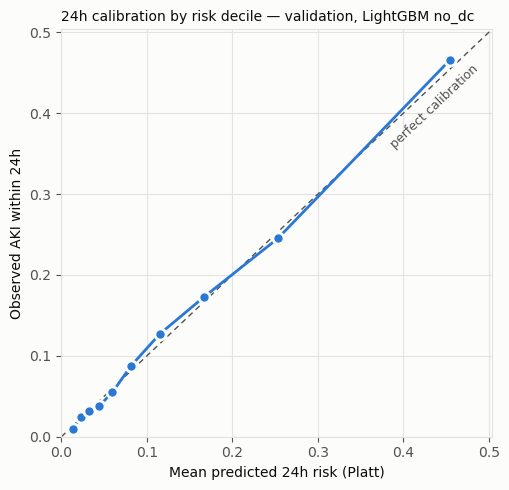

In [6]:
# Calibration curve of the 24h Platt risk (deciles of predicted risk), validation.
g = elig[elig["horizon_h"] == H]
bins = pd.qcut(g[risk_col], 10, duplicates="drop")
cal = g.groupby(bins, observed=True).agg(predicted=(risk_col, "mean"), observed=("label", "mean"), n=("label", "size"))
cal.to_csv(OUT / "calibration_24h_validation.csv")

INK, MUTED, GRID, SURFACE, SERIES = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb", "#2a78d6"
fig, ax = plt.subplots(figsize=(5.2, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
top = float(max(cal["predicted"].max(), cal["observed"].max()) * 1.08)
ax.plot([0, top], [0, top], color=MUTED, lw=1, ls=(0, (4, 3)))
ax.text(top * 0.97, top * 0.90, "perfect calibration", color=MUTED, fontsize=9, ha="right", rotation=45,
        rotation_mode="anchor", transform_rotates_text=True)
ax.plot(cal["predicted"], cal["observed"], color=SERIES, lw=2, marker="o", ms=8, mec=SURFACE, mew=2)
ax.set_xlim(0, top), ax.set_ylim(0, top)
ax.set_xlabel("Mean predicted 24h risk (Platt)", color=INK)
ax.set_ylabel("Observed AKI within 24h", color=INK)
ax.set_title("24h calibration by risk decile — validation, LightGBM no_dc", color=INK, fontsize=10, loc="left")
ax.grid(color=GRID, lw=0.8)
for s in ax.spines.values():
    s.set_color(GRID)
ax.tick_params(colors=MUTED)
fig.tight_layout()
fig.savefig(OUT / "calibration_24h_validation.png", dpi=150, facecolor=SURFACE)
plt.show()

## Part 5 — Write the locked policy for the scoring script

`policy.json` holds the dashboard `threshold` object (Data Contract v1) plus provenance. The scoring script refuses
to attach a threshold unless `locked` is true and the model file hashes match.

In [7]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


metadata = json.loads((MODEL_DIR / "metadata.json").read_text(encoding="utf-8"))
basis = (f"Validation split of run {DEMO['run_id']} (hourly, eligible rows, {monitoring_window}): highest AKI event "
         f"detection rate with <= {DEMO['max_false_alerts_per_patient_day']:g} false alert per patient-day under a "
         f"{DEMO['cooldown_hours']} h repeat-alert cooldown (detection {ALERT_METRICS['event_detection_rate']:.3f}, "
         f"{ALERT_METRICS['false_alerts_per_patient_day']:.3f} false alerts/patient-day, median lead "
         f"{ALERT_METRICS['lead_time_median_h']:.1f} h). Demo setting, not a clinical threshold; no test-set evaluation.")
policy = {
    "policy_version": DEMO["policy_version"],
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "model": {"run_id": DEMO["run_id"], "family": DEMO["family"], "feature_set": DEMO["feature_set"],
              "model_dir": str(MODEL_DIR.relative_to(REPO_ROOT)).replace("\\", "/"),
              "pipeline_sha256": sha256(MODEL_DIR / "pipeline.joblib"),
              "feature_order_sha256": sha256(MODEL_DIR / "feature_order.json")},
    "alert_horizon_h": H,
    "display_horizons_h": [h for h in DEMO["horizons_h"] if h != H],
    "cooldown_hours": DEMO["cooldown_hours"],
    "monitoring_hours": [MONITOR_HOURS[0], MONITOR_HOURS[-1]] if not failed else MONITOR_HOURS,
    "threshold": {"value": THRESHOLD, "comparison": DEMO["comparison"],
                  "validation_run_id": f"{DEMO['run_id']}/validation",
                  "policy_version": DEMO["policy_version"], "monitoring_window": monitoring_window,
                  "calibration_version": f"{DEMO['calibration']} (fit on train OOF, {DEMO['run_id']})",
                  "locked": True, "selection_basis": basis},
    "validation_alert_metrics": ALERT_METRICS,
    "segments_failing_24h": failed,
    "test_set_used": False,
}
assert len(basis) <= 2000
(OUT / "policy.json").write_text(json.dumps(policy, indent=2), encoding="utf-8")
print(json.dumps(policy["threshold"], indent=2))
print("written:", sorted(p.name for p in OUT.iterdir()))

{
  "value": 0.085,
  "comparison": ">=",
  "validation_run_id": "aki_ml_v1_28e0b1fb83/validation",
  "policy_version": "demo-v0",
  "monitoring_window": "ICU hours 1-72",
  "calibration_version": "platt (fit on train OOF, aki_ml_v1_28e0b1fb83)",
  "locked": true,
  "selection_basis": "Validation split of run aki_ml_v1_28e0b1fb83 (hourly, eligible rows, ICU hours 1-72): highest AKI event detection rate with <= 1 false alert per patient-day under a 12 h repeat-alert cooldown (detection 0.935, 0.996 false alerts/patient-day, median lead 13.6 h). Demo setting, not a clinical threshold; no test-set evaluation."
}
written: ['calibration_24h_validation.csv', 'calibration_24h_validation.png', 'policy.json', 'segment_check_validation.csv', 'threshold_grid_validation.csv', 'validation_discrimination.csv']
